In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Setting to make numbers easier to read on display
pd.options.display.float_format = '{:20.2f}'.format

# Show all columns on output
pd.set_option('display.max_columns', 999)

In [2]:
df = pd.read_csv("./data/data_to_be_cleaned.csv")

df

,TransactionID,Client,Beneficiary,AmountUSD,TransactionDateTime,ClientTier
0,1,Darth Vader,Luke Skywalker,120.50,2024-06-01 12:30,Gold
1,2,<Frodo Baggins>,Gandalf the Grey,NaN,2024-06-01 12:31,Silver
2,3,Tony Stark,Bruce Banner,300.40,2024-06-01 12:32,Gold
3,4,Tony Stark,Bruce Banner,300.40,2024-06-01 12:32,Gold
4,5,Jon Snow.,Daenerys Targaryen,150.75,2024-06-01 12:33,Platinum
5,6,Harry*Potter,Hermione Granger,200.00,2024-06-01 12:34,Gold
6,7,Luke Skywalker,Han Solo,90.00,2024-06-01 12:35,Silver
7,8,Katniss Everdeen,Peeta Mellark,120.00,2024-06-01 12:36,Bronze
8,9,Michael Scott.,Dwight Schrute,85.00,2024-06-01 12:37,Silver
9,10,Walter White,Jesse Pinkman,70.00,2024-06-01 12:38,Gold


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        40 non-null     int64  
 1   Client               38 non-null     object 
 2   Beneficiary          40 non-null     object 
 3   AmountUSD            38 non-null     float64
 4   TransactionDateTime  40 non-null     object 
 5   ClientTier           37 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 2.0+ KB


In [4]:
cleaned_df = df.copy()

cleaned_df.dropna(subset=["Client"], inplace=True)

cleaned_df

,TransactionID,Client,Beneficiary,AmountUSD,TransactionDateTime,ClientTier
0,1,Darth Vader,Luke Skywalker,120.50,2024-06-01 12:30,Gold
1,2,<Frodo Baggins>,Gandalf the Grey,NaN,2024-06-01 12:31,Silver
2,3,Tony Stark,Bruce Banner,300.40,2024-06-01 12:32,Gold
3,4,Tony Stark,Bruce Banner,300.40,2024-06-01 12:32,Gold
4,5,Jon Snow.,Daenerys Targaryen,150.75,2024-06-01 12:33,Platinum
5,6,Harry*Potter,Hermione Granger,200.00,2024-06-01 12:34,Gold
6,7,Luke Skywalker,Han Solo,90.00,2024-06-01 12:35,Silver
7,8,Katniss Everdeen,Peeta Mellark,120.00,2024-06-01 12:36,Bronze
8,9,Michael Scott.,Dwight Schrute,85.00,2024-06-01 12:37,Silver
9,10,Walter White,Jesse Pinkman,70.00,2024-06-01 12:38,Gold


In [5]:
cleaned_df.drop_duplicates(subset=["Client", "Beneficiary", "AmountUSD", "TransactionDateTime", "ClientTier"], inplace=True)

cleaned_df

,TransactionID,Client,Beneficiary,AmountUSD,TransactionDateTime,ClientTier
0,1,Darth Vader,Luke Skywalker,120.50,2024-06-01 12:30,Gold
1,2,<Frodo Baggins>,Gandalf the Grey,NaN,2024-06-01 12:31,Silver
2,3,Tony Stark,Bruce Banner,300.40,2024-06-01 12:32,Gold
4,5,Jon Snow.,Daenerys Targaryen,150.75,2024-06-01 12:33,Platinum
5,6,Harry*Potter,Hermione Granger,200.00,2024-06-01 12:34,Gold
6,7,Luke Skywalker,Han Solo,90.00,2024-06-01 12:35,Silver
7,8,Katniss Everdeen,Peeta Mellark,120.00,2024-06-01 12:36,Bronze
8,9,Michael Scott.,Dwight Schrute,85.00,2024-06-01 12:37,Silver
9,10,Walter White,Jesse Pinkman,70.00,2024-06-01 12:38,Gold
10,11,Tony Stark,Peter Parker,320.50,2024-06-01 12:39,Gold


In [6]:
cleaned_df["Client"].str.replace("[a-zA-Z0-9 ]", "", regex=True).unique()

array(['', '<>', '.', '*', '--'], dtype=object)

In [7]:
cleaned_df["Client"] = cleaned_df["Client"].str.strip("<>.*- ")
cleaned_df["Client"] = cleaned_df["Client"].str.replace("*", " ")

cleaned_df

,TransactionID,Client,Beneficiary,AmountUSD,TransactionDateTime,ClientTier
0,1,Darth Vader,Luke Skywalker,120.50,2024-06-01 12:30,Gold
1,2,Frodo Baggins,Gandalf the Grey,NaN,2024-06-01 12:31,Silver
2,3,Tony Stark,Bruce Banner,300.40,2024-06-01 12:32,Gold
4,5,Jon Snow,Daenerys Targaryen,150.75,2024-06-01 12:33,Platinum
5,6,Harry Potter,Hermione Granger,200.00,2024-06-01 12:34,Gold
6,7,Luke Skywalker,Han Solo,90.00,2024-06-01 12:35,Silver
7,8,Katniss Everdeen,Peeta Mellark,120.00,2024-06-01 12:36,Bronze
8,9,Michael Scott,Dwight Schrute,85.00,2024-06-01 12:37,Silver
9,10,Walter White,Jesse Pinkman,70.00,2024-06-01 12:38,Gold
10,11,Tony Stark,Peter Parker,320.50,2024-06-01 12:39,Gold


In [8]:
cleaned_df["Client"] = cleaned_df["Client"].str.upper()
cleaned_df["Beneficiary"] = cleaned_df["Beneficiary"].str.upper()

cleaned_df

,TransactionID,Client,Beneficiary,AmountUSD,TransactionDateTime,ClientTier
0,1,DARTH VADER,LUKE SKYWALKER,120.50,2024-06-01 12:30,Gold
1,2,FRODO BAGGINS,GANDALF THE GREY,NaN,2024-06-01 12:31,Silver
2,3,TONY STARK,BRUCE BANNER,300.40,2024-06-01 12:32,Gold
4,5,JON SNOW,DAENERYS TARGARYEN,150.75,2024-06-01 12:33,Platinum
5,6,HARRY POTTER,HERMIONE GRANGER,200.00,2024-06-01 12:34,Gold
6,7,LUKE SKYWALKER,HAN SOLO,90.00,2024-06-01 12:35,Silver
7,8,KATNISS EVERDEEN,PEETA MELLARK,120.00,2024-06-01 12:36,Bronze
8,9,MICHAEL SCOTT,DWIGHT SCHRUTE,85.00,2024-06-01 12:37,Silver
9,10,WALTER WHITE,JESSE PINKMAN,70.00,2024-06-01 12:38,Gold
10,11,TONY STARK,PETER PARKER,320.50,2024-06-01 12:39,Gold


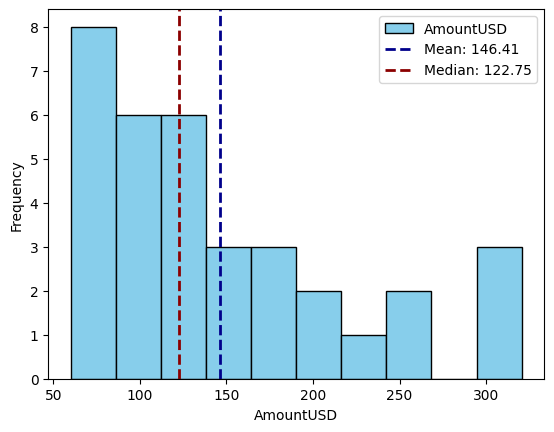

In [12]:
mean_value = cleaned_df["AmountUSD"].mean()
median_value = cleaned_df['AmountUSD'].median()


ax = cleaned_df['AmountUSD'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
ax.set_ylabel('Frequency')
ax.set_xlabel('AmountUSD')

ax.axvline(mean_value, color='darkblue', linestyle='dashed', linewidth=2, label=f'Mean: {mean_value:.2f}')
ax.axvline(median_value, color='darkred', linestyle='dashed', linewidth=2, label=f'Median: {median_value:.2f}')

ax.legend()

plt.show()

In [14]:
np.mean(np.abs(cleaned_df['AmountUSD'] - mean_value))

np.float64(59.06384083044982)

In [15]:
np.mean(np.abs(cleaned_df['AmountUSD'] - median_value))

np.float64(55.79117647058824)

In [17]:
cleaned_df.fillna({"AmountUSD": median_value}, inplace=True)
cleaned_df

,TransactionID,Client,Beneficiary,AmountUSD,TransactionDateTime,ClientTier
0,1,DARTH VADER,LUKE SKYWALKER,120.50,2024-06-01 12:30,Gold
1,2,FRODO BAGGINS,GANDALF THE GREY,122.75,2024-06-01 12:31,Silver
2,3,TONY STARK,BRUCE BANNER,300.40,2024-06-01 12:32,Gold
4,5,JON SNOW,DAENERYS TARGARYEN,150.75,2024-06-01 12:33,Platinum
5,6,HARRY POTTER,HERMIONE GRANGER,200.00,2024-06-01 12:34,Gold
6,7,LUKE SKYWALKER,HAN SOLO,90.00,2024-06-01 12:35,Silver
7,8,KATNISS EVERDEEN,PEETA MELLARK,120.00,2024-06-01 12:36,Bronze
8,9,MICHAEL SCOTT,DWIGHT SCHRUTE,85.00,2024-06-01 12:37,Silver
9,10,WALTER WHITE,JESSE PINKMAN,70.00,2024-06-01 12:38,Gold
10,11,TONY STARK,PETER PARKER,320.50,2024-06-01 12:39,Gold


In [18]:
tier_counts = cleaned_df["ClientTier"].value_counts()

tier_counts


ClientTier
Gold        13
Silver       9
Platinum     6
Bronze       5
Name: count, dtype: int64

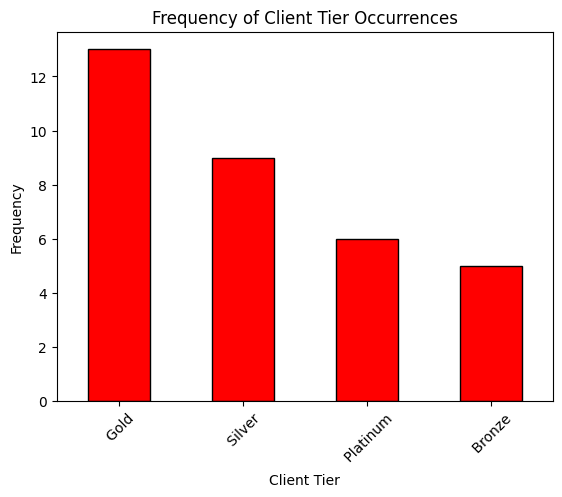

In [19]:
# Plotting
tier_counts.plot(kind='bar', color='red', edgecolor='black')
plt.xlabel('Client Tier')
plt.ylabel('Frequency')
plt.title('Frequency of Client Tier Occurrences')
plt.xticks(rotation=45) # Rotates labels to avoid overlap
plt.show()

In [20]:
# If we replace the other values for example with the most occuring element, we will be introducing quite an amount of error. 20/33 = 0.6

In [25]:
cleaned_df["ClientTier"] = cleaned_df["ClientTier"].str.strip()

client_tier_mode = cleaned_df["ClientTier"].mode()[0]
client_tier_mode

'Gold'

In [27]:
cleaned_df.fillna({"ClientTier": client_tier_mode}, inplace=True)
cleaned_df

,TransactionID,Client,Beneficiary,AmountUSD,TransactionDateTime,ClientTier
0,1,DARTH VADER,LUKE SKYWALKER,120.50,2024-06-01 12:30,Gold
1,2,FRODO BAGGINS,GANDALF THE GREY,122.75,2024-06-01 12:31,Silver
2,3,TONY STARK,BRUCE BANNER,300.40,2024-06-01 12:32,Gold
4,5,JON SNOW,DAENERYS TARGARYEN,150.75,2024-06-01 12:33,Platinum
5,6,HARRY POTTER,HERMIONE GRANGER,200.00,2024-06-01 12:34,Gold
6,7,LUKE SKYWALKER,HAN SOLO,90.00,2024-06-01 12:35,Silver
7,8,KATNISS EVERDEEN,PEETA MELLARK,120.00,2024-06-01 12:36,Bronze
8,9,MICHAEL SCOTT,DWIGHT SCHRUTE,85.00,2024-06-01 12:37,Silver
9,10,WALTER WHITE,JESSE PINKMAN,70.00,2024-06-01 12:38,Gold
10,11,TONY STARK,PETER PARKER,320.50,2024-06-01 12:39,Gold
